# Assignment 01: Linear Regression from Scratch

**Module:** 01 — Classical ML Foundations  
**Estimated Time:** 6-8 hours  
**Difficulty:** Intermediate

---

## Learning Objectives

- Implement batch, stochastic, and mini-batch gradient descent from scratch
- Implement the closed-form normal equation solution: $\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$
- Build intuition for learning rate selection and loss landscape geometry
- Apply linear regression to real data with feature scaling and polynomial features

### Key Equations

**MSE Loss:**
$$L(\mathbf{w}, b) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

**Gradient (vectorized):**
$$\frac{\partial L}{\partial \mathbf{w}} = \frac{2}{n} \mathbf{X}^T (\mathbf{X}\mathbf{w} + b - \mathbf{y}), \quad \frac{\partial L}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)$$

**Update Rule:**
$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \frac{\partial L}{\partial \mathbf{w}}, \quad b \leftarrow b - \alpha \frac{\partial L}{\partial b}$$

In [1]:
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression as SklearnLR
from sklearn.metrics import mean_squared_error, r2_score

# Add project root to path for shared utilities
sys.path.insert(0, '../../')
from shared_utils.common import set_seed

set_seed(42)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Setup complete.')

Setup complete.


## Helper Functions

In [3]:
def generate_synthetic_data(n_samples: int = 200, n_features: int = 1,
                            noise_std: float = 5.0, seed: int = 42):
    """Generate synthetic regression data: y = 3*x + 7 + noise (1D) or random linear combo."""
    np.random.seed(seed)
    X = np.random.randn(n_samples, n_features) * 5
    if n_features == 1:
        y = 3 * X[:, 0] + 7 + np.random.randn(n_samples) * noise_std
    else:
        true_w = np.random.randn(n_features) * 3
        y = X @ true_w + 7 + np.random.randn(n_samples) * noise_std
    return X, y


def compute_mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Compute Mean Squared Error."""
    return np.mean((y_true - y_pred) ** 2)


def compute_r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Compute R-squared (coefficient of determination)."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot


def plot_loss_curves(loss_histories: dict, title: str = 'Loss Curves',
                     log_scale: bool = False):
    """Plot multiple loss curves on the same figure.
    
    Args:
        loss_histories: dict mapping label -> list of loss values
        title: plot title
        log_scale: whether to use log scale on y-axis
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    for label, losses in loss_histories.items():
        ax.plot(losses, label=label, alpha=0.8)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('MSE Loss')
    ax.set_title(title)
    if log_scale:
        ax.set_yscale('log')
    ax.legend()
    plt.tight_layout()
    plt.show()


print('Helpers loaded.')

Helpers loaded.


---
## Part 1A: Batch Gradient Descent (15 points)

Implement the `LinearRegressionGD` class that trains using batch gradient descent.

At each iteration, compute the MSE loss over **all** samples and update the weights:

$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \cdot \frac{2}{n} \mathbf{X}^T (\mathbf{X}\mathbf{w} + b - \mathbf{y})$$
$$b \leftarrow b - \alpha \cdot \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)$$

**Requirements:**
- Vectorized gradient computation (no Python loops over samples)
- Store the loss at each iteration in `self.loss_history`

In [6]:
class LinearRegressionGD:
    """Linear regression trained via batch gradient descent."""

    def __init__(self, learning_rate: float = 0.01, n_iterations: int = 1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights: np.ndarray = None  # shape: (n_features,)
        self.bias: float = None
        self.loss_history: list[float] = []

    def fit(self, X: np.ndarray, y: np.ndarray) -> 'LinearRegressionGD':
        """Train using batch gradient descent.

        Args:
            X: Training features, shape (n_samples, n_features)
            y: Training targets, shape (n_samples,)

        Returns:
            self
        """
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.n_iterations):
            # YOUR CODE HERE
            # 1. Compute predictions: y_pred = X @ w + b
            # 2. Compute errors: errors = y_pred - y
            # 3. Compute MSE loss and append to self.loss_history
            # 4. Compute gradients (vectorized):
            #    dw = (2/n) * X^T @ errors
            #    db = (2/n) * sum(errors)
            # 5. Update weights and bias
            
            y_pred = X @ self.weights + self.bias
            errors = y_pred - y
            self.loss_history.append(np.mean(errors **2))
            dw = (2/n_samples) * X.T @ errors
            db = (2/n_samples) * sum(errors)

            self.weights = self.weights -  self.lr * dw
            self.bias=  self.bias - self.lr * db


        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Return predictions.

        Args:
            X: Features, shape (n_samples, n_features)

        Returns:
            Predictions, shape (n_samples,)
        """
        # YOUR CODE HERE

        return self.X @ self.weights + self.bias
        

Learned weight: 3.1009 (expected ~3.0)
Learned bias:   7.4499 (expected ~7.0)
Final loss:     24.0133


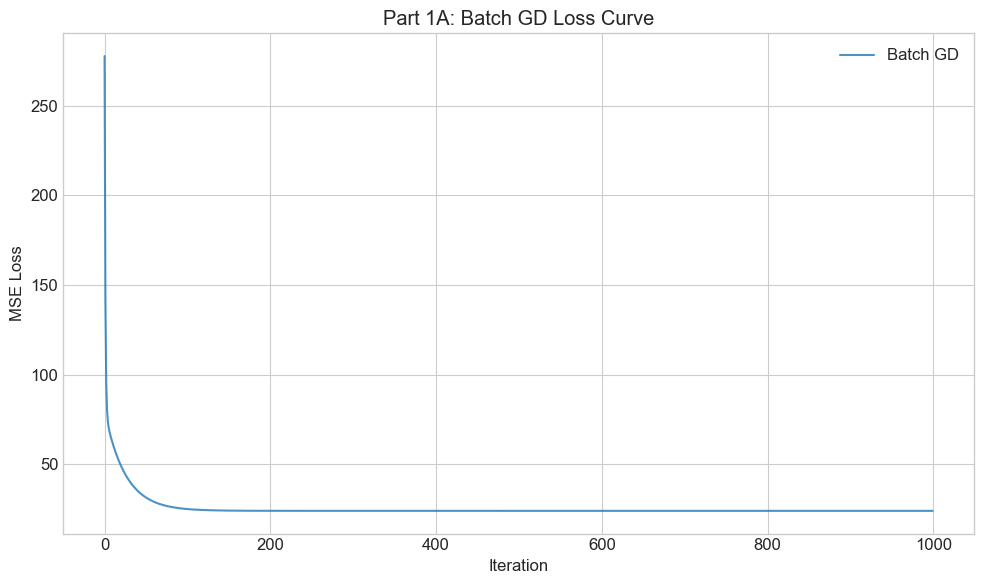

Part 1A tests passed!


In [7]:
# --- Test Part 1A ---
X_synth, y_synth = generate_synthetic_data(n_samples=200, n_features=1, noise_std=5.0)

model_bgd = LinearRegressionGD(learning_rate=0.01, n_iterations=1000)
model_bgd.fit(X_synth, y_synth)

print(f'Learned weight: {model_bgd.weights[0]:.4f} (expected ~3.0)')
print(f'Learned bias:   {model_bgd.bias:.4f} (expected ~7.0)')
print(f'Final loss:     {model_bgd.loss_history[-1]:.4f}')

assert model_bgd.loss_history is not None, 'loss_history should not be None'
assert len(model_bgd.loss_history) == 1000, 'Should have 1000 loss values'
assert model_bgd.loss_history[-1] < model_bgd.loss_history[0], 'Loss should decrease'
assert abs(model_bgd.weights[0] - 3.0) < 1.0, 'Weight should be close to 3'
assert abs(model_bgd.bias - 7.0) < 2.0, 'Bias should be close to 7'

plot_loss_curves({'Batch GD': model_bgd.loss_history}, title='Part 1A: Batch GD Loss Curve')
print('Part 1A tests passed!')

---
## Part 1B: Stochastic Gradient Descent (10 points)

Implement SGD: for each epoch, shuffle the data, then update weights using **one sample at a time**.

The loss curve should be noisier than batch GD because each update uses only one sample's gradient.

In [16]:
class LinearRegressionSGD:
    """Linear regression trained via stochastic gradient descent."""

    def __init__(self, learning_rate: float = 0.01, n_iterations: int = 1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights: np.ndarray = None
        self.bias: float = None
        self.loss_history: list[float] = []

    def fit(self, X: np.ndarray, y: np.ndarray) -> 'LinearRegressionSGD':
        """Train using stochastic gradient descent.

        For each epoch, shuffle the data, then update weights one sample at a time.
        Record the MSE loss over all samples at the end of each epoch.

        Args:
            X: shape (n_samples, n_features)
            y: shape (n_samples,)
        """
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for epoch in range(self.n_iterations):
            # YOUR CODE HERE
            # 1. Create a shuffled index array
            # 2. For each sample i in shuffled order:
            #    - Compute prediction for sample i
            #    - Compute gradient for sample i
            #    - Update weights and bias
            # 3. After all samples, compute epoch loss and append to loss_history

            indicies= np.random.permutation(n_samples) 
            for i in indicies:
                xi = X[i:i+1]
                yi = y[i:i+1]
                ypredi = xi @ self.weights + self.bias
                errors = ypredi - yi
                dw  = 2 * xi.T @ errors
                db =  2 * np.sum(errors)
                self.weights =  self.weights - self.lr * dw
                self.bias  =  self.bias - self.lr * db

                self.loss_history.append(np.mean(errors**2))

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # YOUR CODE HERE
        return X @ self.weights + self.bias

SGD weight: 3.2340 (expected ~3.0)
SGD bias:   7.4750 (expected ~7.0)


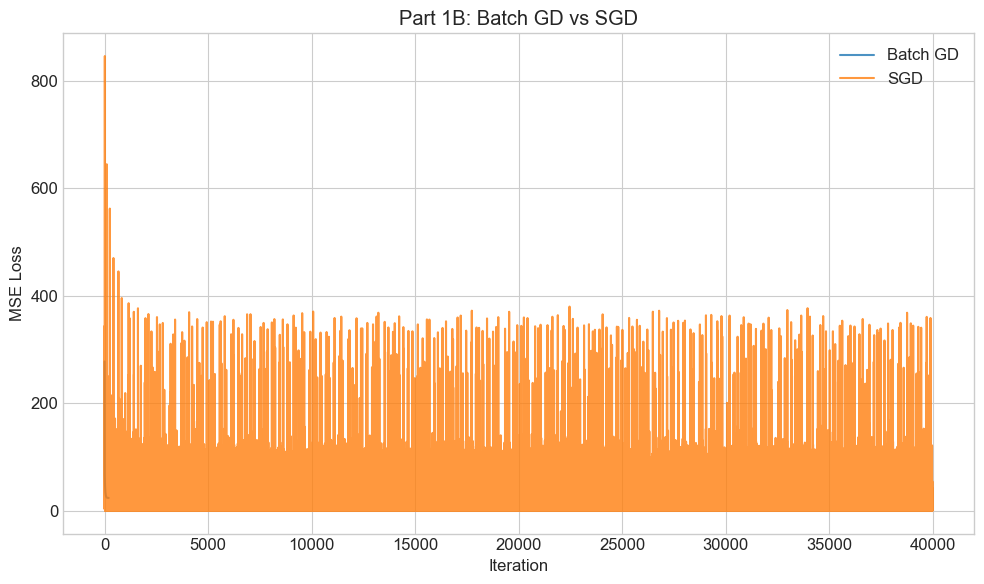

Part 1B tests passed!


In [17]:
# --- Test Part 1B ---
model_sgd = LinearRegressionSGD(learning_rate=0.001, n_iterations=200)
model_sgd.fit(X_synth, y_synth)

print(f'SGD weight: {model_sgd.weights[0]:.4f} (expected ~3.0)')
print(f'SGD bias:   {model_sgd.bias:.4f} (expected ~7.0)')

assert model_sgd.loss_history[-1] < model_sgd.loss_history[0], 'Loss should decrease'

plot_loss_curves({
    'Batch GD': model_bgd.loss_history[:200],
    'SGD': model_sgd.loss_history
}, title='Part 1B: Batch GD vs SGD')
print('Part 1B tests passed!')

---
## Part 1C: Mini-Batch Gradient Descent (15 points)

Implement mini-batch GD with configurable batch size. Compare batch sizes: 1 (SGD), 16, 32, 64, and full batch.

In [ ]:
class LinearRegressionMiniBatch:
    """Linear regression trained via mini-batch gradient descent."""

    def __init__(self, learning_rate: float = 0.01, n_iterations: int = 1000,
                 batch_size: int = 32):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.batch_size = batch_size
        self.weights: np.ndarray = None
        self.bias: float = None
        self.loss_history: list[float] = []

    def fit(self, X: np.ndarray, y: np.ndarray) -> 'LinearRegressionMiniBatch':
        """Train using mini-batch gradient descent.

        Args:
            X: shape (n_samples, n_features)
            y: shape (n_samples,)
        """
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for epoch in range(self.n_iterations):
            # YOUR CODE HERE
            # 1. Shuffle the data
            # 2. Split into mini-batches of size self.batch_size
            # 3. For each mini-batch, compute gradients and update
            # 4. Record epoch loss
            pass

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # YOUR CODE HERE
        pass

In [ ]:
# --- Test Part 1C ---
batch_sizes = [1, 16, 32, 64, len(X_synth)]  # SGD, mini-batches, full batch
loss_curves = {}

for bs in batch_sizes:
    label = f'batch_size={bs}' if bs < len(X_synth) else 'Full Batch'
    model = LinearRegressionMiniBatch(learning_rate=0.005, n_iterations=200, batch_size=bs)
    model.fit(X_synth, y_synth)
    loss_curves[label] = model.loss_history
    print(f'{label}: final loss = {model.loss_history[-1]:.4f}')

plot_loss_curves(loss_curves, title='Part 1C: Mini-Batch Comparison')
print('Part 1C tests passed!')

**Write 2-3 sentences explaining the batch size tradeoff you observe:**

*YOUR ANSWER HERE*

---
## Part 2A: The Normal Equation (10 points)

Implement the closed-form solution:

$$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

Remember to augment $\mathbf{X}$ with a column of ones for the bias term.

In [ ]:
class LinearRegressionNormalEquation:
    """Linear regression solved via the normal equation."""

    def __init__(self):
        self.weights: np.ndarray = None  # shape: (n_features,)
        self.bias: float = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> 'LinearRegressionNormalEquation':
        """Solve using the normal equation: w = (X^T X)^{-1} X^T y.

        Augment X with a column of ones for the bias.

        Args:
            X: shape (n_samples, n_features)
            y: shape (n_samples,)
        """
        # YOUR CODE HERE
        # 1. Augment X with a column of ones: X_aug = [X | 1]
        # 2. Compute w = (X_aug^T @ X_aug)^{-1} @ X_aug^T @ y
        # 3. Split w into weights and bias
        pass

    def predict(self, X: np.ndarray) -> np.ndarray:
        # YOUR CODE HERE
        pass

In [ ]:
# --- Test Part 2A ---
model_ne = LinearRegressionNormalEquation()
model_ne.fit(X_synth, y_synth)

print(f'Normal Equation weight: {model_ne.weights[0]:.4f} (expected ~3.0)')
print(f'Normal Equation bias:   {model_ne.bias:.4f} (expected ~7.0)')

assert abs(model_ne.weights[0] - 3.0) < 1.0, 'Weight should be close to 3'
assert abs(model_ne.bias - 7.0) < 2.0, 'Bias should be close to 7'

# Compare to GD solution
print(f'\nGD weight:  {model_bgd.weights[0]:.4f}')
print(f'NE weight:  {model_ne.weights[0]:.4f}')
print(f'Difference: {abs(model_bgd.weights[0] - model_ne.weights[0]):.6f}')
print('Part 2A tests passed!')

---
## Part 2B: Timing Comparison (5 points)

Compare wall-clock time of the normal equation vs gradient descent for $n = 100, 10000, 100000$ samples with 10 features.

In [ ]:
# --- Part 2B: Timing Comparison ---
sample_sizes = [100, 10_000, 100_000]
n_features = 10

print(f'{"n_samples":>10} | {"Normal Eq (ms)":>15} | {"GD (ms)":>15}')
print('-' * 50)

for n in sample_sizes:
    X_time, y_time = generate_synthetic_data(n_samples=n, n_features=n_features)

    # Time Normal Equation
    start = time.time()
    model_ne_t = LinearRegressionNormalEquation()
    model_ne_t.fit(X_time, y_time)
    ne_time = (time.time() - start) * 1000

    # Time Gradient Descent (500 iterations)
    start = time.time()
    model_gd_t = LinearRegressionGD(learning_rate=0.001, n_iterations=500)
    model_gd_t.fit(X_time, y_time)
    gd_time = (time.time() - start) * 1000

    print(f'{n:>10} | {ne_time:>15.2f} | {gd_time:>15.2f}')

**Write 2-3 sentences about when you would choose each method:**

*YOUR ANSWER HERE*

---
## Part 3A: Learning Rate Sweep (10 points)

Train with learning rates: $\{0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 2.0\}$.

Plot all loss curves on the same figure with log-scale y-axis.

In [ ]:
# --- Part 3A: Learning Rate Sweep ---
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 2.0]
lr_loss_curves = {}

for lr in learning_rates:
    # YOUR CODE HERE
    # Train LinearRegressionGD with each learning rate
    # Store loss history in lr_loss_curves with key f'lr={lr}'
    # For diverging cases, clip loss values to prevent plot issues
    pass

plot_loss_curves(lr_loss_curves, title='Part 3A: Learning Rate Sweep', log_scale=True)

---
## Part 3B: Loss Landscape Visualization (5 points)

For the 1-feature case, create a contour plot of the MSE loss over a grid of $(w, b)$ values.
Overlay the gradient descent trajectory for two learning rates: one that converges smoothly and one that oscillates.

In [ ]:
def compute_loss_landscape(X: np.ndarray, y: np.ndarray,
                           w_range: tuple, b_range: tuple,
                           n_points: int = 100):
    """Compute MSE loss on a grid of (w, b) values.

    Args:
        X: shape (n_samples, 1)
        y: shape (n_samples,)
        w_range: (w_min, w_max)
        b_range: (b_min, b_max)
        n_points: grid resolution

    Returns:
        W_grid, B_grid, Loss_grid: meshgrid arrays
    """
    w_vals = np.linspace(w_range[0], w_range[1], n_points)
    b_vals = np.linspace(b_range[0], b_range[1], n_points)
    W_grid, B_grid = np.meshgrid(w_vals, b_vals)
    Loss_grid = np.zeros_like(W_grid)

    for i in range(n_points):
        for j in range(n_points):
            y_pred = X[:, 0] * W_grid[i, j] + B_grid[i, j]
            Loss_grid[i, j] = np.mean((y_pred - y) ** 2)

    return W_grid, B_grid, Loss_grid


def track_trajectory(X: np.ndarray, y: np.ndarray,
                     lr: float, n_iters: int = 200):
    """Run GD and return the trajectory of (w, b) values."""
    w, b = 0.0, 0.0
    trajectory = [(w, b)]
    n = len(y)
    for _ in range(n_iters):
        y_pred = X[:, 0] * w + b
        errors = y_pred - y
        dw = (2 / n) * np.dot(X[:, 0], errors)
        db = (2 / n) * np.sum(errors)
        w -= lr * dw
        b -= lr * db
        trajectory.append((w, b))
    return np.array(trajectory)

In [ ]:
# --- Part 3B: Loss Landscape ---
# YOUR CODE HERE
# 1. Compute the loss landscape using compute_loss_landscape
# 2. Track trajectories for two learning rates (e.g., 0.01 and 0.1)
# 3. Plot contour with trajectories overlaid
#
# Example plotting structure:
# fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# For each axis:
#   ax.contourf(W_grid, B_grid, Loss_grid, levels=50, cmap='viridis')
#   ax.plot(traj[:, 0], traj[:, 1], 'r.-', markersize=3)
#   ax.set_xlabel('weight (w)')
#   ax.set_ylabel('bias (b)')
pass

---
## Part 4A: Real Data — Dataset Preparation (5 points)

Use the California Housing dataset. Load, examine, split (80/20), and apply feature scaling.

**Why scaling is necessary:** When features have different magnitudes, the loss landscape becomes elongated (ill-conditioned), causing gradient descent to oscillate and converge slowly.

In [ ]:
# --- Part 4A: Load and Prepare Data ---
housing = fetch_california_housing()
X_real, y_real = housing.data, housing.target

print(f'Shape: {X_real.shape}')
print(f'Feature names: {housing.feature_names}')
print(f'Target range: [{y_real.min():.2f}, {y_real.max():.2f}]')

# YOUR CODE HERE
# 1. Split into train/test (80/20)
# 2. Apply StandardScaler (fit on train, transform both)
# X_train, X_test, y_train, y_test = ...
pass

---
## Part 4B: Training and Evaluation (5 points)

Train your GD model on the real data. Report MSE and $R^2$. Compare to sklearn's `LinearRegression`.

In [ ]:
# --- Part 4B: Train and Evaluate ---
# YOUR CODE HERE
# 1. Train your LinearRegressionGD on X_train, y_train
# 2. Predict on X_test
# 3. Compute and print MSE and R^2
# 4. Train sklearn's LinearRegression as sanity check
# 5. Compare results
pass

---
## Part 4C: Polynomial Features (5 points)

Add polynomial features (degree 2, 3, 5) and observe when overfitting occurs.

In [ ]:
# --- Part 4C: Polynomial Features ---
# YOUR CODE HERE
# For degree in [2, 3, 5]:
#   1. Create polynomial features using PolynomialFeatures(degree)
#   2. Scale the polynomial features
#   3. Train your model
#   4. Report train MSE and test MSE
#   5. If test MSE > train MSE by a large margin, overfitting is occurring
pass

---
## Part 5: Written Analysis (15 points)

Answer each question in 2-4 sentences.

### Q1: Why MSE (mean) instead of SSE (sum)?

*YOUR ANSWER HERE*

### Q2: Why subtract the gradient in the update rule?

*YOUR ANSWER HERE*

### Q3: Why might SGD noise be beneficial in deep learning?

*YOUR ANSWER HERE*

### Q4: When is $(\mathbf{X}^T \mathbf{X})$ non-invertible?

*YOUR ANSWER HERE*

### Q5: Why does feature scaling speed up gradient descent? (Geometric intuition)

*YOUR ANSWER HERE*

---
## What I Learned

*Write 3-5 sentences summarizing your key takeaways from this assignment.*